# 02 — NCA 特征提取（从原始 U/I/t 到 50 维）

**流程总览**（每块一个 Cell，可单独调试）：

```
原始parquet(U,I,t) → 放电段检测 → 去IR瞬态 → Q(V)积分 → IC=|dQ/dV|
     → 锚点峰定位(3.35–3.55V, 石墨峰) → ΔV窗口(峰锚定,逐循环移动)
     → 窗内16点: Q / ΔQ(对参考循环) / IC  + 2标量(h_peak, ΔVpeak)
     → 每循环一行50维 + SOH标签(容量CSV时间插值)
```

**三个已被数据锁定的决策**：
1. **锚点 = 3.45 V 附近的石墨主导峰**。依据：cell 025 全寿命追踪 r=0.974（3.8 V 正极峰只有 r=0.45）；跨 DOD 五档 aging 段峰高~时间序 |r| 均 >0.95。
2. **窗口逐循环跟峰移动**（与 LFP 侧同一哲学），宽度 ΔV 待 Cell 7 标定（NCA 峰比 LFP 宽，预计 0.15–0.2 V）。
3. **提取阶段不做任何归一化**（导师规矩）：特征存原始物理值，min-max 留到训练端。

**参考循环的选取**：跳过前 `N_SKIP` 个有效循环（025 的最初几圈形状异常，疑似 formation 效应），取其后连续 `N_REF` 圈的平均峰位作 ΔVpeak 基准、第一圈作 ΔQ 的 Q 参考。

In [1]:
# ---- Cell 1: 环境与参数 ----
import re, json, numpy as np, pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import s3fs
from s3_credentials import S3_ACCESS_KEY, S3_SECRET_KEY

OPTS = {"key": S3_ACCESS_KEY, "secret": S3_SECRET_KEY,
        "client_kwargs": {"endpoint_url": "https://iseadocker.isea.rwth-aachen.de:9000",
                          "region_name": "us-east-1"},
        "config_kwargs": {"s3": {"addressing_style": "path"}, "signature_version": "s3v4"}}
fs = s3fs.S3FileSystem(**OPTS)
TS = lambda s: pd.to_datetime(s, format='ISO8601')

VTC   = "projects/j8005-metabatt/Metabatt/VTC"
CAPD  = f"{VTC}/40_capacity_monitore"
PREFIX = "METABatt_Sony_Murata_18650VTC6_"

# ---- 提取参数(集中一处,答辩可整表展示) ----
P = dict(
    DV_GRID   = 0.002,      # IC电压网格步长 [V]
    SIGMA     = 2,          # Q(V)高斯平滑
    MIN_SEG   = 10,         # 段最少采样点
    I_TH      = 1.0,        # 放电检测阈值 [A] (0.5C≈1.5A, 留余量)
    IR_DROP   = 0.015,      # 去起始IR瞬态: 丢弃 V>V0-15mV 的开头点
    PK_LO     = 3.35,       # 锚点峰搜索区间下限(石墨峰,数据锁定)
    PK_HI     = 3.55,       # 锚点峰搜索区间上限
    HALF_WIN  = 0.08,       # 半窗宽 → ΔV=0.16V  ★Cell 7标定后可改
    N_PTS     = 16,         # 窗内采样点数
    N_SKIP    = 10,         # 跳过最初N个有效循环(formation)
    N_REF     = 5,          # 参考峰位=其后N圈平均
    NOM_AH    = 3.0,        # 标称容量
)
print(json.dumps({k:v for k,v in P.items()}, indent=1))

{
 "DV_GRID": 0.002,
 "SIGMA": 2,
 "MIN_SEG": 10,
 "I_TH": 1.0,
 "IR_DROP": 0.015,
 "PK_LO": 3.35,
 "PK_HI": 3.55,
 "HALF_WIN": 0.08,
 "N_PTS": 16,
 "N_SKIP": 10,
 "N_REF": 5,
 "NOM_AH": 3.0
}


In [2]:
# ---- Cell 2: 待提取电池清单 + SOH标签函数 ----
# 首批: 25℃/0.5C/50%SOC中心 五个DOD档(锚点峰均在运行窗内,已验证)
CELLS = {"025": "100DOD", "081": "80DOD", "203": "60DOD",
         "034": "40DOD",  "005": "20DOD"}

def soh_fn(bid):
    """返回 (插值函数: unix秒→SOH, 锚点数)。原理与LFP侧extract_X_single完全一致:
    check-up标定给出稀疏(时刻,SOH)锚点,循环级标签用时间线性插值——
    容量衰减慢且平滑,插值误差远小于1%SOH。"""
    cap = pd.read_csv(f"s3://{CAPD}/{PREFIX}{bid}_capacity.csv", storage_options=OPTS)
    s = cap.dropna(subset=['SOH']).copy()
    s['t'] = TS(s['CAP_start_time']); s = s.sort_values('t')
    st = s['t'].values.astype('datetime64[s]').astype(np.float64)
    sv = s['SOH'].values
    return (lambda tsec: np.interp(tsec, st, sv)), len(s)

for bid, dod in CELLS.items():
    f, n = soh_fn(bid)
    print(f"cell {bid} ({dod}): {n} SOH锚点")

cell 025 (100DOD): 30 SOH锚点
cell 081 (80DOD): 28 SOH锚点
cell 203 (60DOD): 30 SOH锚点
cell 034 (40DOD): 28 SOH锚点
cell 005 (20DOD): 28 SOH锚点


## Cell 3 原理：放电段检测与 IR 瞬态

**段检测**：`I < -I_TH` 的连续区间就是放电段。用 `np.diff` 找 0→1（段起点）和 1→0（段终点）的跳变，比逐点循环快几个量级。

**IR 瞬态**：放电接通瞬间，欧姆内阻造成电压台阶式骤降，最初几个采样点的 dQ/dV 会被这个非电化学过程污染成一根假峰（你在 025 的黄色曲线上见过）。处理：找到电压首次跌破 `V0 − 15mV` 的位置，之前的点全部丢弃——**从数据源头排除，而不是画图时藏起来**。

In [3]:
# ---- Cell 3: 段检测 + 去IR瞬态 ----
def discharge_segments(d):
    """输入整文件DataFrame(Zeit,Spannung,Strom已就绪), 产出去过IR瞬态的放电段列表"""
    I = d['Strom'].values
    m = I < -P['I_TH']
    diff = np.diff(m.astype(int))
    st = np.where(diff == 1)[0] + 1
    en = np.where(diff == -1)[0] + 1
    if m[0]:  st = np.r_[0, st]
    if m[-1]: en = np.r_[en, len(d)]
    segs = []
    for s, e in zip(st, en):
        if e - s < P['MIN_SEG']: continue
        seg = d.iloc[s:e]
        V = seg['Spannung'].values
        i0 = np.argmax(V < V[0] - P['IR_DROP'])       # 去IR瞬态
        if i0 > 0 and e - s - i0 >= P['MIN_SEG']:
            seg = seg.iloc[i0:]
        segs.append(seg)
    return segs

## Cell 4 原理：从 (t, U, I) 到 Q(V) 和 IC

1. **Q = ∫|I|dt**：电流对时间累积就是放出的电荷，`np.cumsum(|I|·Δt)/3600` 得 Ah。
2. **换轴到电压**：IC 定义在电压轴上。放电时 V 大体单调下降但有测量噪声，先 `argsort` 排序再 `np.unique` 去重复电压点（重复点会让插值除零）。
3. **均匀网格 + 平滑**：把 Q(V) 插值到等间距电压网格（步长 `DV_GRID`），高斯平滑（σ=`SIGMA`）——**先平滑 Q 再求导**，因为求导会放大噪声，直接对原始 Q 求导得到的 IC 全是毛刺。
4. **IC = |dQ/dV|**：`np.gradient` 中心差分。取绝对值是因为放电方向 dQ/dV 为负，我们只关心幅度。

In [4]:
# ---- Cell 4: 段 → (Q曲线, IC曲线) ----
def seg_to_curves(seg):
    """返回 dict: t0(段起始时刻), cap(段容量Ah), Vu/Qu(去重排序后的原始Q(V)),
    vgrid/IC(均匀网格上的IC)。任一步不满足质量要求返回None。"""
    t = (seg['Zeit'] - seg['Zeit'].iloc[0]).dt.total_seconds().values
    V = seg['Spannung'].values
    Q = np.cumsum(np.abs(seg['Strom'].values) * np.diff(t, prepend=t[0]) / 3600.0)
    o = np.argsort(V)
    Vu, idx = np.unique(V[o], return_index=True)
    Qu = Q[o][idx]
    if len(Vu) < 5: return None
    vgrid = np.arange(Vu.min() + 0.01, Vu.max() - 0.01, P['DV_GRID'])
    if len(vgrid) < 30: return None
    Qsm = gaussian_filter1d(np.interp(vgrid, Vu, Qu), sigma=P['SIGMA'])
    IC = np.abs(np.gradient(Qsm, vgrid))
    return dict(t0=seg['Zeit'].iloc[0], cap=float(Q[-1]),
                Vu=Vu, Qu=Qu, vgrid=vgrid, IC=IC)

## Cell 5 原理：锚点峰定位与覆盖检查

**为什么限定区间找峰而不是全局 argmax**：NCA 全电池 IC 有 4–5 个结构，全局最大值常被 ~3.95 V 的高 SOC 端结构或残余瞬态抢走。锚点必须是**携带老化信息的那个**——3.35–3.55 V 的石墨主导峰（r=0.974 的实证依据）。

**覆盖检查**：段的电压范围必须真正跨过峰区（两侧各留半窗），否则该段无法提取——浅 DOD 或碎段会在这里被自然过滤，这就是"window-covers-peak"判据的代码形态。

In [5]:
# ---- Cell 5: 锚点峰 ----
def anchor_peak(vgrid, IC):
    """在锚点区间内找峰。返回(峰位V, 峰高)或None(区间未覆盖)"""
    lo_need = P['PK_LO'] - P['HALF_WIN']
    hi_need = P['PK_HI'] + P['HALF_WIN']
    if vgrid.min() > P['PK_LO'] or vgrid.max() < P['PK_HI']:
        return None                                   # 峰区未被本段覆盖
    m = (vgrid >= P['PK_LO']) & (vgrid <= P['PK_HI'])
    if m.sum() < 5: return None
    i = np.argmax(IC[m])
    return float(vgrid[m][i]), float(IC[m][i])

## Cell 6 原理：50 维特征的确切定义

设本循环锚点峰位为 `v_pk`，窗口 = `[v_pk − HALF_WIN, v_pk + HALF_WIN]`，窗内均匀取 `N_PTS=16` 个电压点 `v_1..v_16`（**窗口跟峰走**——峰老化左移，窗口随之左移）。

- **Q 序列**：`Q(v_i)` ——从段起点放到电压 v_i 时已释放的电荷。同一电池同一工况下段起点 SOC 一致，故跨循环可比。
- **ΔQ 序列**：`Q(v_i) − Q_ref(v_i)` ——参考循环的 Q(V) 曲线在**当前窗口的电压点**上插值后逐点相减。这是"形变先于容量衰减"的早期预警信号。
- **IC 序列**：`IC(v_i)` ——窗内局部峰形本身。
- **h_peak**：锚点峰高（原始值，NCA 上叠在斜坡背景上——是否改为相对背景峰高留作开放参数，v1 保持与 LFP 管线一致的原始定义）。
- **ΔVpeak**：`v_ref_avg − v_pk` ——**本电池自己**早期 N_REF 圈平均峰位减当前峰位（放电峰随老化向低压移动，此定义下随老化增大）。

跨电池绝对差异（容量、起始 SOC）由训练端的域内 min-max 消化；提取端只存物理原值。

In [6]:
# ---- Cell 6: 单电池完整提取 ----
def extract_cell(bid):
    soh_of, _ = soh_fn(bid)
    base = f"{VTC}/{PREFIX}{bid}"
    files = [f for f in sorted(fs.ls(base)) if f.endswith('.parquet')]

    # -- pass 1: 收集所有可用循环的曲线(内存换清晰;单电池可承受) --
    cycles = []
    for f in files:
        with fs.open(f) as fh:
            d = pq.ParquetFile(fh).read(columns=['Zeit','Spannung','Strom']).to_pandas()
        d['Zeit'] = TS(d['Zeit'])
        for seg in discharge_segments(d):
            c = seg_to_curves(seg)
            if c is None: continue
            pk = anchor_peak(c['vgrid'], c['IC'])
            if pk is None: continue
            c['v_pk'], c['h_pk'] = pk
            cycles.append(c)
    cycles.sort(key=lambda c: c['t0'])
    if len(cycles) <= P['N_SKIP'] + P['N_REF']:
        print(f"cell {bid}: 有效循环过少({len(cycles)}), 跳过"); return None

    # -- pass 2: 定参考(跳过formation) --
    ref_pool = cycles[P['N_SKIP'] : P['N_SKIP'] + P['N_REF']]
    v_ref = float(np.mean([c['v_pk'] for c in ref_pool]))
    Q_ref_V, Q_ref_Q = ref_pool[0]['Vu'], ref_pool[0]['Qu']   # ΔQ参考曲线

    # -- pass 3: 逐循环出50维 --
    rows = []
    for c in cycles[P['N_SKIP']:]:
        vw = np.linspace(c['v_pk'] - P['HALF_WIN'], c['v_pk'] + P['HALF_WIN'], P['N_PTS'])
        Qw  = np.interp(vw, c['Vu'], c['Qu'])
        Qrw = np.interp(vw, Q_ref_V, Q_ref_Q)     # 参考曲线在当前窗电压上的取值
        ICw = np.interp(vw, c['vgrid'], c['IC'])
        row = dict(BID=bid, t0=c['t0'], cap=c['cap'],
                   SOH=float(soh_of(np.float64(pd.Timestamp(c['t0']).value)//10**9)),
                   h_peak=c['h_pk'], dVpeak=v_ref - c['v_pk'])
        for i in range(P['N_PTS']):
            row[f"Q_{i:02d}"]  = Qw[i]
            row[f"dQ_{i:02d}"] = Qw[i] - Qrw[i]
            row[f"IC_{i:02d}"] = ICw[i]
        rows.append(row)
    out = pd.DataFrame(rows)
    print(f"cell {bid}: {len(out)}行, SOH {out['SOH'].min():.1f}~{out['SOH'].max():.1f}, "
          f"参考峰位 {v_ref:.3f}V")
    return out

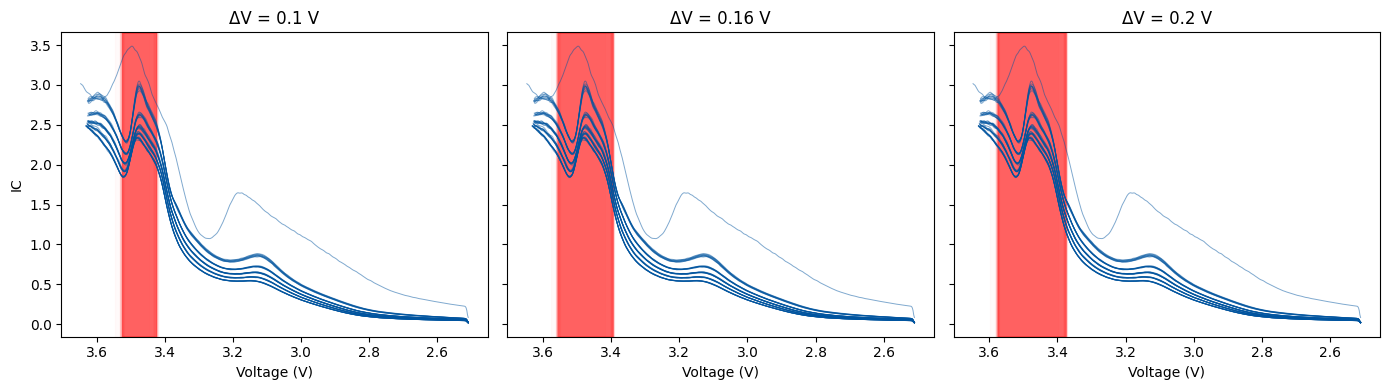

In [7]:
# ---- Cell 7: 窗宽ΔV标定(先跑这格再定HALF_WIN, 方法与LFP定0.1V同款) ----
BID_CAL = "025"
soh_of, _ = soh_fn(BID_CAL)
base = f"{VTC}/{PREFIX}{BID_CAL}"
files = [f for f in sorted(fs.ls(base)) if f.endswith('.parquet')]
cal = []
for f in files[::max(1,len(files)//12)]:            # 稀疏抽文件,标定够用
    with fs.open(f) as fh:
        d = pq.ParquetFile(fh).read(columns=['Zeit','Spannung','Strom']).to_pandas()
    d['Zeit'] = TS(d['Zeit'])
    for seg in discharge_segments(d):
        c = seg_to_curves(seg)
        if c and anchor_peak(c['vgrid'], c['IC']): cal.append(c)
cal = cal[::max(1,len(cal)//40)]
fig, axes = plt.subplots(1, 3, figsize=(14,4), sharey=True)
for ax, dv in zip(axes, [0.10, 0.16, 0.20]):
    for c in cal:
        vpk,_ = anchor_peak(c['vgrid'], c['IC'])
        m = c['vgrid'] <= vpk + 0.15
        ax.plot(c['vgrid'][m], c['IC'][m], lw=0.7, alpha=0.5, color='#00549F')
        ax.axvspan(vpk-dv/2, vpk+dv/2, color='red', alpha=0.02)
    ax.set_title(f'ΔV = {dv} V'); ax.set_xlabel('Voltage (V)'); ax.invert_xaxis()
axes[0].set_ylabel('IC')
plt.tight_layout(); plt.savefig('nca_window_calibration.png', dpi=150); plt.show()
# 目检标准: 窗口应罩住主峰完整形状(含两肩), 但不吞进3.6V邻峰。定好后回Cell 1改HALF_WIN。

In [8]:
# ---- Cell 8: 批量提取 + 落盘 ----
all_parts = []
for bid in CELLS:
    part = extract_cell(bid)
    if part is not None:
        part.to_parquet(f"nca_features_{bid}.parquet")
        all_parts.append(part)
nca = pd.concat(all_parts, ignore_index=True)
nca.to_parquet("nca_features_all.parquet")
print("total rows:", len(nca), "→ nca_features_all.parquet")

cell 025: 1924行, SOH 65.1~94.5, 参考峰位 3.482V
cell 081: 2068行, SOH 63.5~94.3, 参考峰位 3.482V
cell 203: 2556行, SOH 54.8~95.4, 参考峰位 3.466V
cell 034: 3814行, SOH 59.0~96.1, 参考峰位 3.458V
cell 005: 75行, SOH 74.3~90.7, 参考峰位 3.481V
total rows: 10437 → nca_features_all.parquet


C:\Users\zho-xli\AppData\Local\Temp\ipykernel_2144\243508718.py:14: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('nca_extract_qa.png', dpi=150); plt.show()
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_2144\243508718.py:14: UserWarning: Glyph 26395 (\N{CJK UNIFIED IDEOGRAPH-671B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('nca_extract_qa.png', dpi=150); plt.show()
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_2144\243508718.py:14: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('nca_extract_qa.png', dpi=150); plt.show()
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_2144\243508718.py:14: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('nca_extract_qa.png', dpi=150); plt.show()
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_2144\2

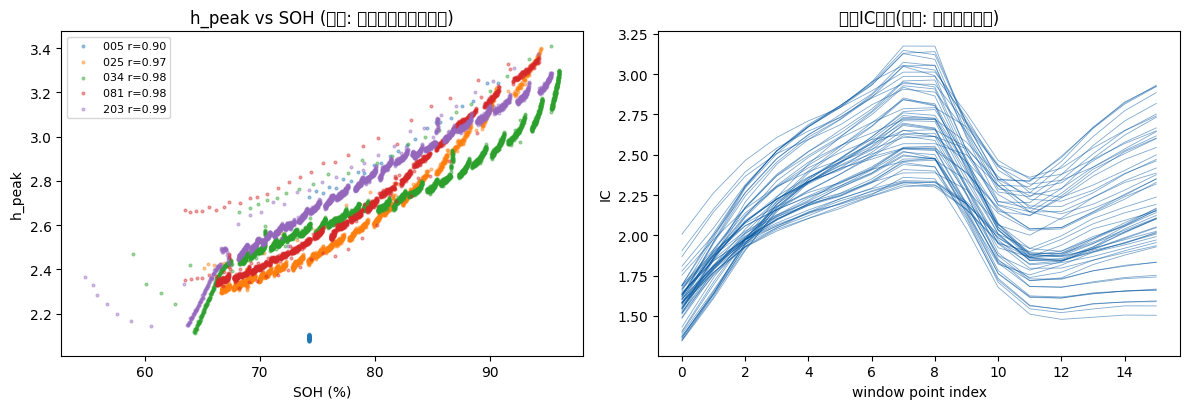

In [9]:
# ---- Cell 9: 质检 —— 每颗电池 h_peak~SOH 相关 + 抽样序列形状 ----
fig, ax = plt.subplots(1, 2, figsize=(12,4.2))
for bid, g in nca.groupby('BID'):
    r = np.corrcoef(g['SOH'], g['h_peak'])[0,1]
    ax[0].scatter(g['SOH'], g['h_peak'], s=4, alpha=0.4, label=f"{bid} r={r:.2f}")
ax[0].set_xlabel('SOH (%)'); ax[0].set_ylabel('h_peak'); ax[0].legend(fontsize=8)
ax[0].set_title('h_peak vs SOH (期望: 各电池内单调正相关)')
sample = nca.sample(min(60,len(nca)), random_state=0)
ic_cols = [f"IC_{i:02d}" for i in range(16)]
for _, row in sample.iterrows():
    ax[1].plot(range(16), row[ic_cols].values, lw=0.6, alpha=0.5, color='#00549F')
ax[1].set_xlabel('window point index'); ax[1].set_ylabel('IC')
ax[1].set_title('抽样IC序列(期望: 峰形完整居中)')
plt.tight_layout(); plt.savefig('nca_extract_qa.png', dpi=150); plt.show()

## 开放参数备忘（答辩可主动列出）

| 参数 | 当前值 | 状态 |
|---|---|---|
| `HALF_WIN` | 0.08 (ΔV=0.16V) | Cell 7 目检后定稿 |
| h_peak 定义 | 原始峰高 | NCA 有斜坡背景，"相对背景峰高"为备选方案 |
| 段来源 | aging 段 | 首批五颗窗口均覆盖峰；窗口不覆盖的工况需改用 CU 段 |
| 参考循环 | 跳过前 10 圈 | 基于 025 早期曲线异常的观察 |